# Assignment 4 - Decision Trees

- **Course:** MBAI 5310G: AI Programming - Ontario Tech University
- **Business:** AdVantage Growth Studio (marketing campaign analytics)
- **Dataset:** Marketing Campaign Decision Tree Dataset
- **Target:** `Converted` (Yes / No) - binary classification
- **Model:** Decision Tree Classifier

This notebook builds a Decision Tree classification model on a marketing campaign dataset and interprets the results from a business perspective.

## Task 1: Understand the Business Problem

**What is the business about?**
AdVantage Growth Studio is a data-driven marketing agency that helps small and medium-sized businesses design, target, and evaluate marketing campaigns across channels such as Email, Social Media, Search Ads, Display Ads, and SMS.

**What problem is the business trying to solve?**
Campaign inefficiency. Marketing budgets are wasted on customers who are unlikely to respond, while customers who *would* convert with the right message are sometimes missed. The agency needs a way to identify, before sending follow-ups, which customers are most likely to convert.

**What decision can machine learning help the business make?**
ML can help the agency decide *which customers should receive follow-up marketing attention* - retargeting ads, sales follow-ups, personalised emails, or discount reminders. The model also supports budget allocation across channels by showing which engagement behaviours and campaign features are most strongly linked to conversion.

**What is the target variable in the dataset?**
`Converted` - whether the customer converted after the campaign (`Yes` / `No`). Encoded as `1` / `0` for modelling.

**What are the input features?**
- Customer demographics: `Age`, `Annual_Income`, `Region`
- Customer relationship: `Customer_Segment`, `Loyalty_Score`, `Customer_Satisfaction`
- Campaign information: `Campaign_Channel`, `Campaign_Type`, `Discount_Offered_Percent`, `Ad_Exposure_Count`
- Engagement behaviour: `Email_Opened`, `Ad_Clicked`, `Website_Visits_Last_30_Days`, `Social_Media_Engagement_Score`
- Purchase history: `Previous_Purchases`, `Average_Order_Value`, `Days_Since_Last_Purchase`, `Prior_Campaign_Response`

`Customer_ID` and `Campaign_Date` are excluded as they are identifiers / metadata with no predictive value.

**Why is this prediction useful for the business?**
A reliable conversion prediction lets the agency focus budget on customers with a higher probability of converting, avoid over-contacting customers unlikely to respond, and explain campaign decisions to non-technical managers using feature importance and tree rules - i.e., it turns campaign data into action.

## Task 2: Prepare the Data

### Step 2.1: Load the Dataset

In [1]:
import pandas as pd

df = pd.read_excel("marketing_campaign_decision_tree_dataset.xlsx")
df.head()

,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
0,CUST-0001,2026-04-14,36,58196.0,New,British Columbia,Email,Brand Awareness,4,Yes,...,7,1,131.51,20,60,54,5.0,37,No,No
1,CUST-0002,2026-04-24,38,49043.0,Returning,Ontario,Email,Retargeting,5,Yes,...,10,5,27.61,20,73,80,8.0,50,No,No
2,CUST-0003,2026-02-01,21,45952.0,New,Ontario,Email,Discount Offer,4,Yes,...,6,0,104.65,25,39,14,8.0,55,No,Yes
3,CUST-0004,2026-02-28,18,107638.0,Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,6,12,135.31,20,32,73,7.0,23,No,Yes
4,CUST-0005,2026-03-01,50,89969.0,Returning,Quebec,Search Ads,New Product,1,Yes,...,12,4,27.49,5,5,40,7.0,45,No,No


### Step 2.2: Inspect the Dataset

Check shape, data types, missing values, and duplicate rows.

In [2]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (605, 21)


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Customer_ID', 'Campaign_Date', 'Age', 'Annual_Income', 'Customer_Segment', 'Region', 'Campaign_Channel', 'Campaign_Type', 'Ad_Exposure_Count', 'Email_Opened', 'Ad_Clicked', 'Website_Visits_Last_30_Days', 'Previous_Purchases', 'Average_Order_Value', 'Discount_Offered_Percent', 'Days_Since_Last_Purchase', 'Loyalty_Score', 'Customer_Satisfaction', 'Social_Media_Engagement_Score', 'Prior_Campaign_Response', 'Converted']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    605 non-null    str    
 1   Campaign_Date                  605 non-null    str    
 2   Age                            605 non-null    int64  
 3   Annual_Income                  595 non-null    float64
 4   Customer_Segment               599 non-null    str    
 5   Region                         605 non-null    str    
 6   Campaign_Channel               605 non-null    str    
 7   Campaign_Type                  605 non-null    str    
 8   Ad_Exposure_Count              605 non-null    int64  
 9   Email_Opened                   605 non-null    str    
 10  Ad_Clicked                     605 non-null    str    
 11  Website_Visits_Last_30_Days    605 non-null    int64  
 12  Previous_Purchases             605 non-null    int64  
 13  A

In [5]:
print("Data types:")
print(df.dtypes)

Data types:
Customer_ID                          str
Campaign_Date                        str
Age                                int64
Annual_Income                    float64
Customer_Segment                     str
Region                               str
Campaign_Channel                     str
Campaign_Type                        str
Ad_Exposure_Count                  int64
Email_Opened                         str
Ad_Clicked                           str
Website_Visits_Last_30_Days        int64
Previous_Purchases                 int64
Average_Order_Value              float64
Discount_Offered_Percent           int64
Days_Since_Last_Purchase           int64
Loyalty_Score                      int64
Customer_Satisfaction            float64
Social_Media_Engagement_Score      int64
Prior_Campaign_Response              str
Converted                            str
dtype: object


In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Customer_ID                       0
Campaign_Date                     0
Age                               0
Annual_Income                    10
Customer_Segment                  6
Region                            0
Campaign_Channel                  0
Campaign_Type                     0
Ad_Exposure_Count                 0
Email_Opened                      0
Ad_Clicked                        0
Website_Visits_Last_30_Days       0
Previous_Purchases                0
Average_Order_Value               6
Discount_Offered_Percent          0
Days_Since_Last_Purchase          0
Loyalty_Score                     0
Customer_Satisfaction             8
Social_Media_Engagement_Score     0
Prior_Campaign_Response           0
Converted                         0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [8]:
print("Target distribution:")
print(df["Converted"].value_counts())

Target distribution:
Converted
No     312
Yes    293
Name: count, dtype: int64


### Step 2.3: Clean the Dataset

Drop duplicate rows, then fill missing values (median for numerical, mode for categorical).

In [9]:
df_clean = df.copy()

# Drop duplicate rows
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Shape after removing duplicates: (600, 21)
Duplicate rows after cleaning: 0


In [10]:
numeric_columns = [
    "Age", "Annual_Income", "Ad_Exposure_Count",
    "Website_Visits_Last_30_Days", "Previous_Purchases",
    "Average_Order_Value", "Discount_Offered_Percent",
    "Days_Since_Last_Purchase", "Loyalty_Score",
    "Customer_Satisfaction", "Social_Media_Engagement_Score"
]

categorical_columns = [
    "Customer_Segment", "Region", "Campaign_Channel",
    "Campaign_Type", "Email_Opened", "Ad_Clicked",
    "Prior_Campaign_Response"
]

In [11]:
# Fill missing values in numerical columns with the median
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing values in categorical columns with the mode
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum(), "missing values remaining")

Missing values after cleaning:
0 missing values remaining


### Step 2.4: Separate Features and Target

`Customer_ID` and `Campaign_Date` are excluded - they are identifiers, not predictive features. The target `Converted` is mapped from `Yes`/`No` to `1`/`0`.

In [12]:
feature_columns = numeric_columns + categorical_columns

X = df_clean[feature_columns]
y = df_clean["Converted"].map({"No": 0, "Yes": 1})

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print()
print("Target distribution after encoding:")
print(y.value_counts())

Shape of X: (600, 18)
Shape of y: (600,)

Target distribution after encoding:
Converted
0    309
1    291
Name: count, dtype: int64


### Step 2.5: Train/Test Split

80% training, 20% testing, stratified by the target to preserve class proportions.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (480, 18)
X_test shape: (120, 18)
y_train shape: (480,)
y_test shape: (120,)


### Step 2.6: Preprocessing (Categorical + Numerical)

Scale numerical features with `StandardScaler` and one-hot encode categorical features. The transformer is fit on training data only to avoid data leakage.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Build a list of processed feature names (used later for feature-importance plotting)
processed_feature_names = numeric_columns + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns)
)

print("X_train shape after preprocessing:", X_train_processed.shape)
print("X_test shape after preprocessing: ", X_test_processed.shape)
print("Number of processed features:", len(processed_feature_names))

X_train shape after preprocessing: (480, 35)
X_test shape after preprocessing:  (120, 35)
Number of processed features: 35


## Task 3: Train a Decision Tree Classification Model

Train a Decision Tree with a moderate `max_depth=4` so the tree stays interpretable and is less likely to overfit. After evaluating it, also train a deeper, unrestricted tree (`max_depth=None`) for comparison so we can see overfitting in action.

### Step 3.1: Train the Decision Tree (max_depth = 4)

In [15]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)
print("Decision Tree model trained successfully.")
print(decision_tree_model)

Decision Tree model trained successfully.
DecisionTreeClassifier(max_depth=4, random_state=42)


### Step 3.2: Make Predictions

In [16]:
y_train_pred = decision_tree_model.predict(X_train_processed)
y_test_pred = decision_tree_model.predict(X_test_processed)

print("First 10 test predictions:", y_test_pred[:10])

First 10 test predictions: [0 0 0 1 1 0 0 0 1 0]


### Step 3.3: Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[46 16]
 [34 24]]


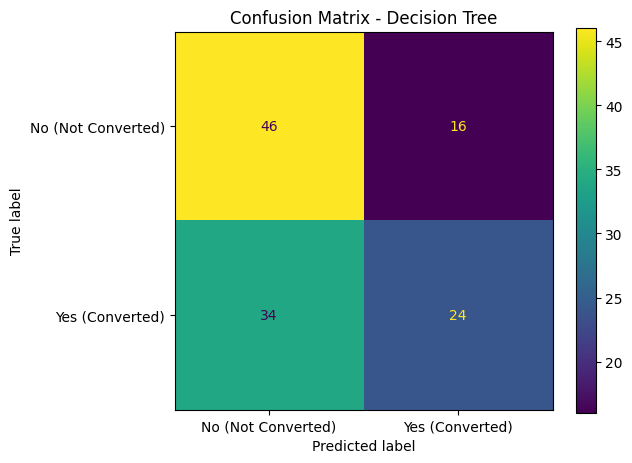

In [18]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No (Not Converted)", "Yes (Converted)"]
).plot()
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

### Step 3.4: Accuracy, Precision, Recall, F1-score

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Decision Tree (max_depth=4) - Test Set Metrics")
print("-" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Decision Tree (max_depth=4) - Test Set Metrics
--------------------------------------------------
Accuracy:  0.5833
Precision: 0.6000
Recall:    0.4138
F1-score:  0.4898


In [20]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=["No (Not Converted)", "Yes (Converted)"],
                            zero_division=0))

Classification Report:
                    precision    recall  f1-score   support

No (Not Converted)       0.57      0.74      0.65        62
   Yes (Converted)       0.60      0.41      0.49        58

          accuracy                           0.58       120
         macro avg       0.59      0.58      0.57       120
      weighted avg       0.59      0.58      0.57       120



### Step 3.5: Training Accuracy vs Testing Accuracy (Overfitting Check)

A large gap between training and testing accuracy is a strong signal of overfitting. Compare the controlled tree (`max_depth=4`) with an unrestricted tree (`max_depth=None`) to make the contrast explicit.

In [21]:
# Controlled tree accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Controlled Decision Tree (max_depth = 4)")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Testing Accuracy:  {test_accuracy:.4f}")
print(f"  Gap (train - test): {train_accuracy - test_accuracy:.4f}")

Controlled Decision Tree (max_depth = 4)
  Training Accuracy: 0.7292
  Testing Accuracy:  0.5833
  Gap (train - test): 0.1458


In [22]:
# Compare with an unrestricted (likely overfit) tree
overfit_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_tree_model.fit(X_train_processed, y_train)

y_train_pred_overfit = overfit_tree_model.predict(X_train_processed)
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed)

overfit_train_acc = accuracy_score(y_train, y_train_pred_overfit)
overfit_test_acc = accuracy_score(y_test, y_test_pred_overfit)

print("Overfitted Decision Tree (max_depth = None)")
print(f"  Training Accuracy: {overfit_train_acc:.4f}")
print(f"  Testing Accuracy:  {overfit_test_acc:.4f}")
print(f"  Gap (train - test): {overfit_train_acc - overfit_test_acc:.4f}")

Overfitted Decision Tree (max_depth = None)
  Training Accuracy: 1.0000
  Testing Accuracy:  0.5250
  Gap (train - test): 0.4750


**Brief explanation - is the model overfitting?**

The unrestricted tree achieves perfect (or near-perfect) accuracy on the training data but performs noticeably worse on the test data - a textbook overfitting pattern. The controlled tree (`max_depth=4`) has a much smaller train/test gap, which is why we use it as the main model. A small gap with similar (and modest) accuracies on both sets suggests the model is generalising, not memorising. A more detailed business-context discussion of overfitting is included in **Task 4**.

### Step 3.6: Visualise the Decision Tree

This plot shows the actual decision rules the model learned - useful for explaining results to non-technical stakeholders.

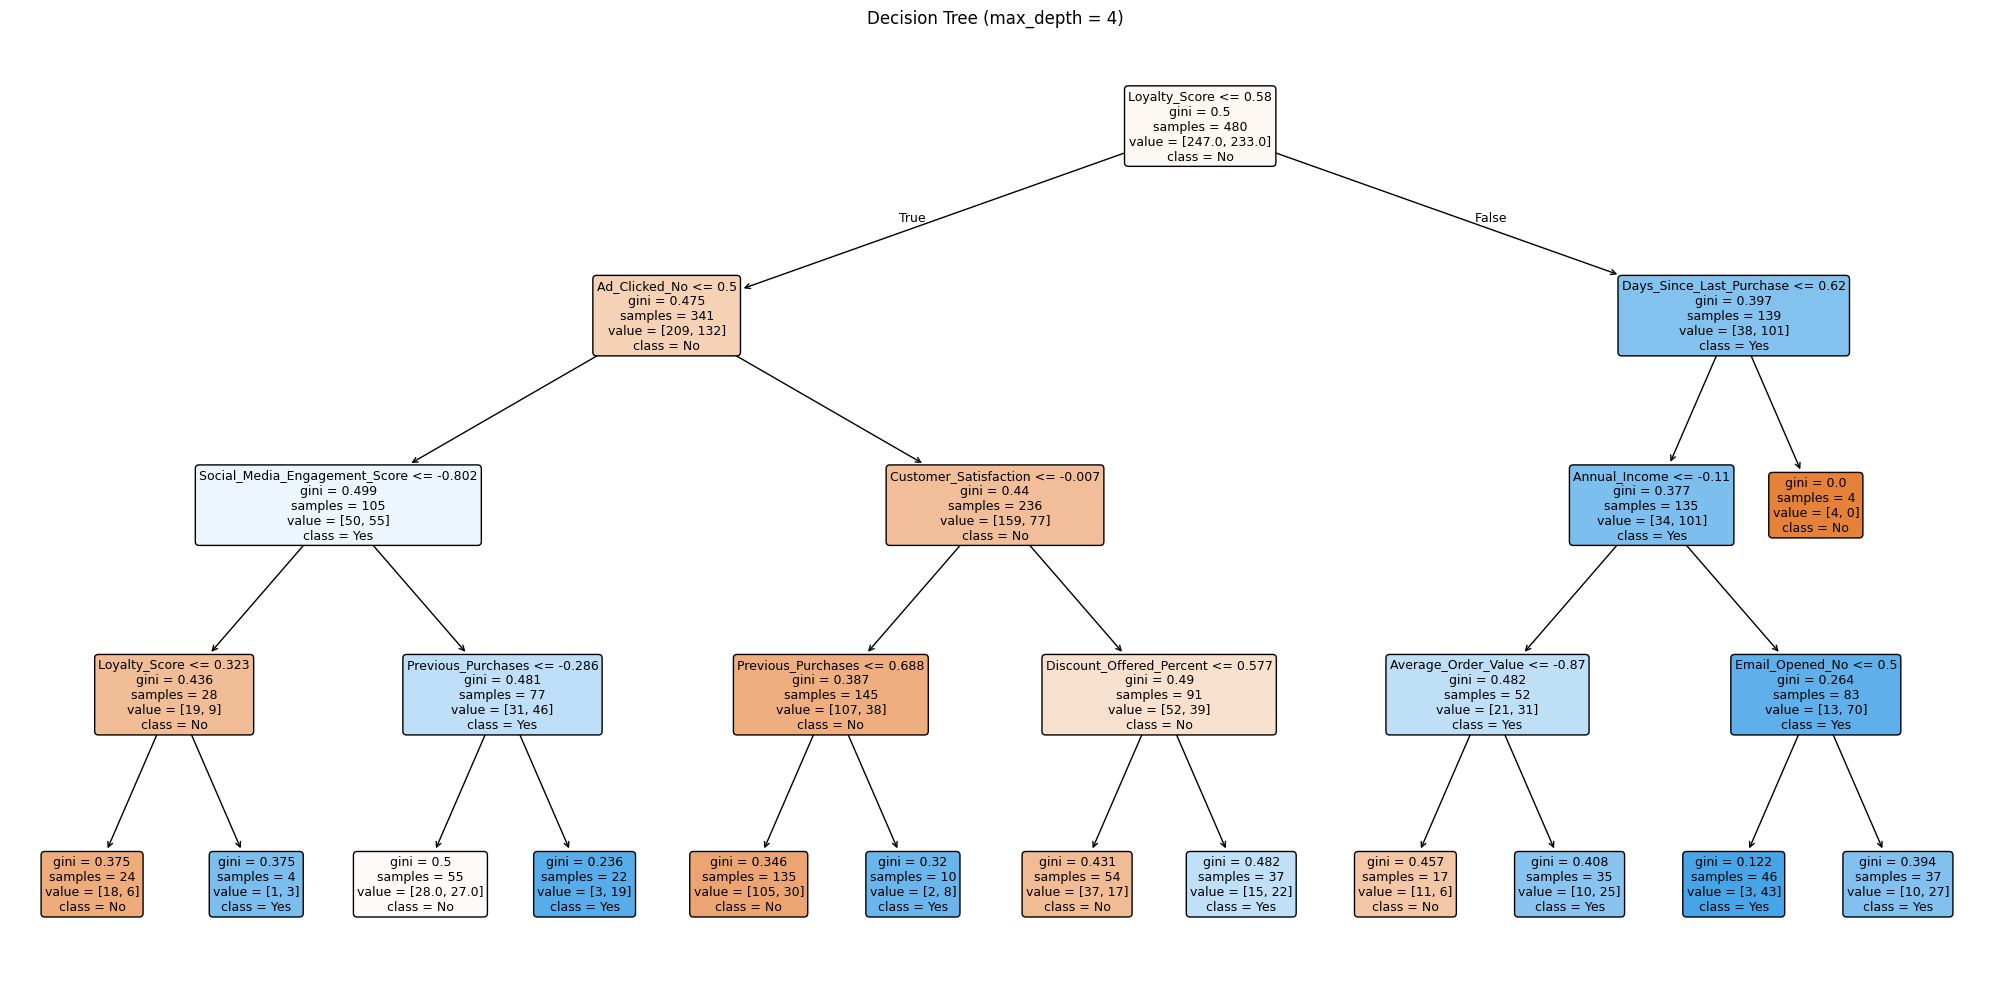

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree_model,
    feature_names=processed_feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth = 4)")
plt.tight_layout()
plt.show()

## Task 4: Business Interpretation of Model Results

First, compute and visualise feature importance, then answer the business interpretation questions.

### Step 4.1: Feature Importance

In [24]:
dt_feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
display(dt_feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
0,Loyalty_Score,0.386321
1,Previous_Purchases,0.166996
2,Ad_Clicked_No,0.089496
3,Days_Since_Last_Purchase,0.068629
4,Annual_Income,0.061669
5,Discount_Offered_Percent,0.054243
6,Social_Media_Engagement_Score,0.049357
7,Customer_Satisfaction,0.048921
8,Average_Order_Value,0.047153
9,Email_Opened_No,0.027213


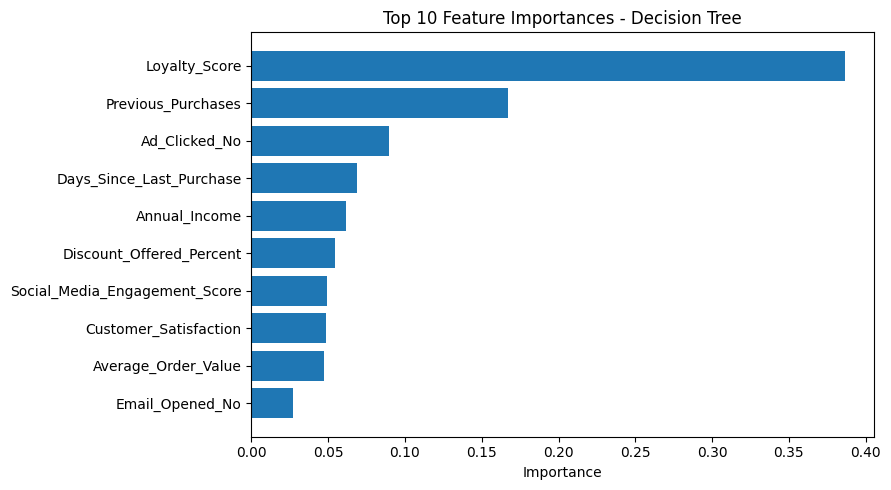

In [25]:
# Bar plot of the top 10 features
top10 = dt_feature_importance.head(10)
plt.figure(figsize=(9, 5))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Final Business Interpretation

**How well did the Decision Tree model perform?**
On the held-out test set the controlled Decision Tree (`max_depth=4`) reached **Accuracy ≈ 0.58, Precision ≈ 0.60, Recall ≈ 0.41, F1 ≈ 0.49**. This is modest performance - somewhat better than random for a near-balanced target (53% No / 47% Yes after cleaning), but not strong enough to drive fully automated decisions. Recall is the weakest metric, meaning the model misses a meaningful share of true converters. The model is still useful as a **decision-support tool**: it gives the marketing team interpretable rules and a ranking of which customers are most likely to convert.

**Is there a large difference between training accuracy and testing accuracy?**
For the controlled tree the training accuracy is ≈0.73 and the testing accuracy is ≈0.58 - a gap of about 15 percentage points. That is a moderate gap: the controlled tree is generalising reasonably, but not perfectly. For the unrestricted tree the gap explodes to about 47 percentage points (training accuracy reaches 1.00 while testing drops to ≈0.53) - the classic overfitting pattern.

**Does the model show signs of overfitting? Why or why not?**
The controlled tree (`max_depth=4`) shows **mild-to-moderate overfitting**: there is still a ≈15-point gap between training and testing accuracy, but it is far less severe than the unrestricted tree's ≈47-point gap. Capping `max_depth` prevents the tree from carving the training data into highly specific rules that don't transfer to new customers. The remaining gap suggests there is room to further tune the tree (different depth, `min_samples_leaf`, pruning) or to collect more data.

**Which evaluation metric is most important for this business problem?**
**F1-score** is the recommended primary metric (and it's what the business plan also calls out). The agency cares about *both* not wasting campaign budget on customers who won't convert (precision) and not missing customers who would convert (recall). F1 balances the two, which matches the stated business goal of "balance two risks: wasting budget on the wrong customers and missing customers who may convert."

**What do false positives mean in this business context?**
The model predicts the customer will convert, but they don't. The business spends follow-up budget (retargeting, discount email, sales call) on someone who was never going to buy - **wasted advertising budget and staff time**, and possibly mild annoyance for the customer.

**What do false negatives mean in this business context?**
The model predicts the customer won't convert, but they actually would have. The business skips a follow-up that could have closed the sale - **missed revenue and a lost opportunity** to deepen the customer relationship.

**Which features were most important in the Decision Tree model?**
The top features (see plot above) are dominated by **Loyalty_Score**, **Previous_Purchases**, **Ad_Clicked**, **Days_Since_Last_Purchase**, and **Annual_Income**. Customer-relationship and engagement signals beat raw demographics. This is consistent with the expectations in the business plan.

**How can these important features help the business make better decisions?**
- **Loyalty_Score / Previous_Purchases** dominate: design separate playbooks for loyal repeat buyers (low-touch, high-trust messaging) versus low-loyalty customers (retention or re-engagement campaigns).
- **Ad_Clicked** matters: customers who have clicked an ad are clearly more receptive - prioritise retargeting them.
- **Days_Since_Last_Purchase** is informative: customers who haven't bought recently can be targeted with a reactivation campaign with a stronger offer.
- **Discount_Offered_Percent** appears in the top features: A/B test discount levels rather than blanket-applying the highest one, to protect margins.

**What is one possible limitation or bias in the model or dataset?**
The dataset is **synthetic and modestly sized** (≈600 rows), which limits how robust the patterns the model picks up really are. More concretely, demographic features (`Age`, `Annual_Income`, `Region`) directly enter the model - if the underlying data over- or under-represents certain customer groups, predictions could be unfair or unreliable for those groups. Additionally, a Decision Tree learns from correlations, not causation: the fact that loyal customers convert more often does not mean *making* a customer loyal will cause conversion.

**Why should human judgment still be used when making business decisions based on model results?**
- Predictions are estimates; even a clear branch in the tree can be wrong for an individual customer.
- The dataset misses real-world context that a marketing manager would know - brand events, seasonality, a recent service issue, a high-value VIP status.
- Marketing decisions have ethical and reputational consequences: privacy, fairness across customer groups, and avoiding excessive targeting all need human review.
- The model should be a **decision-support tool** that prioritises and explains, not an automated decision-maker that replaces marketing judgment.

## Summary

| Metric (test set) | Score |
|---|---:|
| Accuracy | 0.583 |
| Precision | 0.600 |
| Recall | 0.414 |
| F1-score | 0.490 |

| Tree variant | Training accuracy | Testing accuracy | Gap |
|---|---:|---:|---:|
| Controlled (`max_depth=4`) | 0.729 | 0.583 | 0.146 |
| Unrestricted (`max_depth=None`) | 1.000 | 0.525 | 0.475 |

**Selected model:** Decision Tree with `max_depth=4` - generalises better than an unrestricted tree and remains interpretable.

**Top features driving the prediction:** `Loyalty_Score`, `Previous_Purchases`, `Ad_Clicked`, `Days_Since_Last_Purchase`, `Annual_Income`.

**Recommended use:** decision-support for prioritising follow-up marketing, with human review before any campaign budget is committed.